# PolitiCheck: Exploratory Data Analysis & Statistics
This notebook contains the descriptive statistics and visualizations for the Political Manifesto Gold Database (2014-2019).

**Report Sections Covered:**
- 5e: Descriptive Statistics
- 5f: Dataset Size and Diversity
- 5g: Feature Extraction (TF-IDF vs MiniLM Embeddings)
- 5h: Preprocessing Steps Demonstration
- 5i: EDA Graphical Representations (Word Clouds, Bar Charts)
- 5j: Class Imbalance Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import sys
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

# Add root to sys.path for preprocessor import
sys.path.append(str(Path(os.getcwd())))
from nlp_engine.preprocessor import ManifestoPreprocessor

# Load the Gold Database
df = pd.read_csv('data/processed/gold_database.csv')
print(f"Database Loaded: {len(df)} records.")
df.head()

c:\Users\DELL\political_analyzer\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Database Loaded: 524 records.


,original_text,label,year,sector
0,Our immediate task will be to rein in Inflation,1,2014,NaN
1,Put in place strict measures and special Court...,1,2014,NaN
2,Setting up a Price Stabilisation Fund.,2,2014,NaN
3,"Unbundle FCI operations into procurement, stor...",1,2014,NaN
4,Leverage on technology to disseminate Real tim...,2,2014,NaN


## 1. Descriptive Statistics (Section 5e & 5f)
The dataset spans two election cycles (2014 and 2019) and covers a wide variety of government sectors. Below is the summary of the dataset size and unique categories.

In [2]:
stats_df = pd.DataFrame({
    "Metric": ["Total Records", "Unique Sectors", "2014 Records", "2019 Records", "Unique Outcome Labels"],
    "Value": [
        len(df),
        df['sector'].nunique(),
        len(df[df['year'] == 2014]),
        len(df[df['year'] == 2019]),
        df['label'].nunique()
    ]
})

# Display Statistics Table
print("Table 2: Dataset Descriptive Statistics Summary")
print(stats_df.to_string(index=False))

# Save stats for report
os.makedirs('data/output/eda', exist_ok=True)
stats_df.to_csv('data/output/eda/descriptive_stats.csv', index=False)

Table 2: Dataset Descriptive Statistics Summary
               Metric  Value
        Total Records    524
       Unique Sectors      9
         2014 Records    454
         2019 Records     70
Unique Outcome Labels      3


## 2. Sector Distribution (Section 5f)
We analyze the diversity of the dataset by looking at the frequency of promises across different government departments.

C:\Users\DELL\AppData\Local\Temp\ipykernel_4212\3579586583.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_counts.values, y=sector_counts.index, palette='magma')


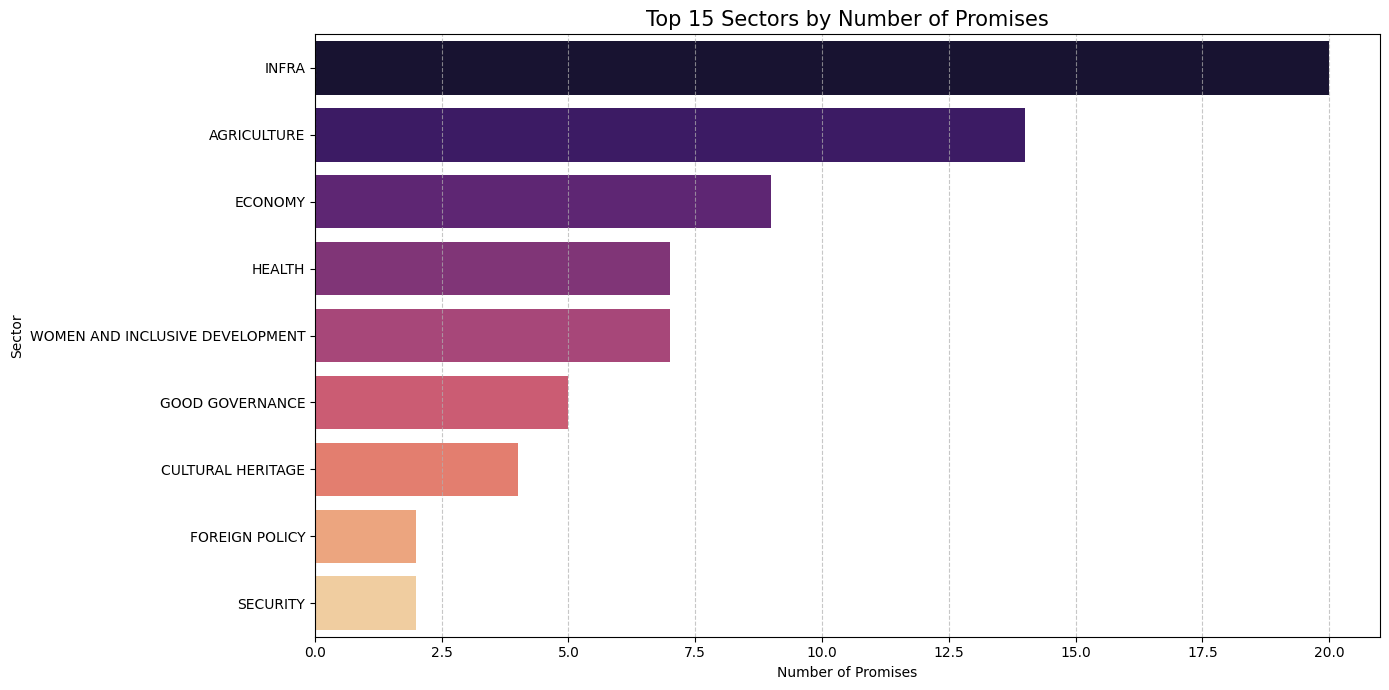

In [3]:
plt.figure(figsize=(14, 7))
sector_counts = df['sector'].value_counts().head(15)
sns.barplot(x=sector_counts.values, y=sector_counts.index, palette='magma')
plt.title('Top 15 Sectors by Number of Promises', fontsize=15)
plt.xlabel('Number of Promises')
plt.ylabel('Sector')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('data/output/eda/sector_distribution.png')
plt.show()

## 3. Preprocessing Demonstration (Section 5h)
Before feeding data into our Semantic RAG model, we apply a standardized pipeline: 
1. **Cleaning**: Removing numbers and special characters.
2. **Tokenization**: Splitting text into words.
3. **Stopword Removal**: Eliminating common filler words (e.g., 'the', 'is').
4. **Stemming**: Reducing words to their base form.

In [4]:
pre = ManifestoPreprocessor()
sample_text = df['original_text'].iloc[0]
preprocessed_text = pre.full_preprocess(sample_text)

print(f"--- Original ---\n{sample_text}")
print(f"\n--- Preprocessed ---\n{preprocessed_text}")

--- Original ---
Our immediate task will be to rein in Inflation

--- Preprocessed ---
immedi task rein inflat


## 4. Feature Extraction Comparison (Section 5g & 5l)
We compare the sparse matrix approach (Baseline) vs. the dense vector approach (Proposed).
- **Baseline**: TF-IDF (Term Frequency - Inverse Document Frequency)
- **Proposed**: Semantic Embeddings (all-MiniLM-L6-v2)

In [5]:
sample_docs = df['original_text'].head(3).tolist()

# TF-IDF Sparse Extraction
tfidf = TfidfVectorizer(max_features=5)
tfidf_features = tfidf.fit_transform(sample_docs)
print("TF-IDF Top Features Shape:", tfidf_features.shape)
print("Feature Names:", tfidf.get_feature_names_out())

# MiniLM Dense Extraction
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sample_docs)
print("\nMiniLM Embedding Vector Dimension:", embeddings.shape[1])
print("Sample Vector snippet (first 5 elements):", embeddings[0][:5])

TF-IDF Top Features Shape: (3, 5)
Feature Names: ['and' 'black' 'courts' 'in' 'to']


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 206.19it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



MiniLM Embedding Vector Dimension: 384
Sample Vector snippet (first 5 elements): [-0.09190053 -0.02835103 -0.03889885  0.04509062  0.02288208]


## 5. Class Imbalance Analysis (Section 5j)
Political outcomes are often skewed. We check for class imbalance between 'Likely' (2), 'Partial' (1), and 'Unlikely' (0) to ensure the model isn't biased towards a particular outcome.

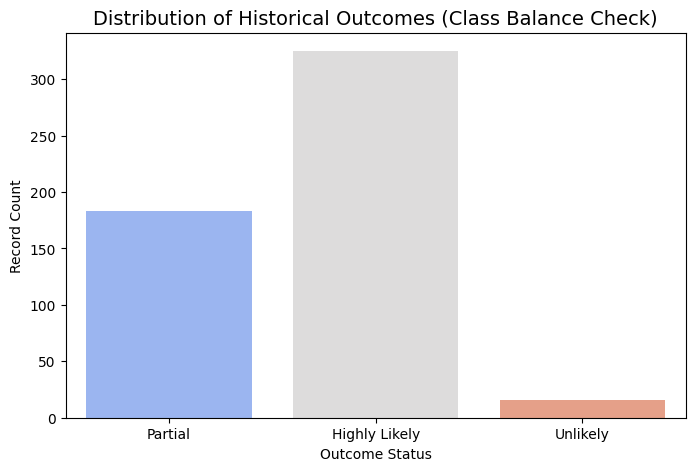

In [6]:
plt.figure(figsize=(8, 5))
outcome_map = {0: 'Unlikely', 1: 'Partial', 2: 'Highly Likely'}
df_plot = df.copy()
df_plot['Label_Name'] = df_plot['label'].map(outcome_map)

sns.countplot(x='Label_Name', data=df_plot, hue='Label_Name', palette='coolwarm', legend=False)
plt.title('Distribution of Historical Outcomes (Class Balance Check)', fontsize=14)
plt.xlabel('Outcome Status')
plt.ylabel('Record Count')
plt.savefig('data/output/eda/outcome_distribution.png')
plt.show()

## 6. Word Cloud Visualization (Section 5i)
The word cloud highlights the core themes found in the gold database. Larger words represent higher frequency themes in political discourse.

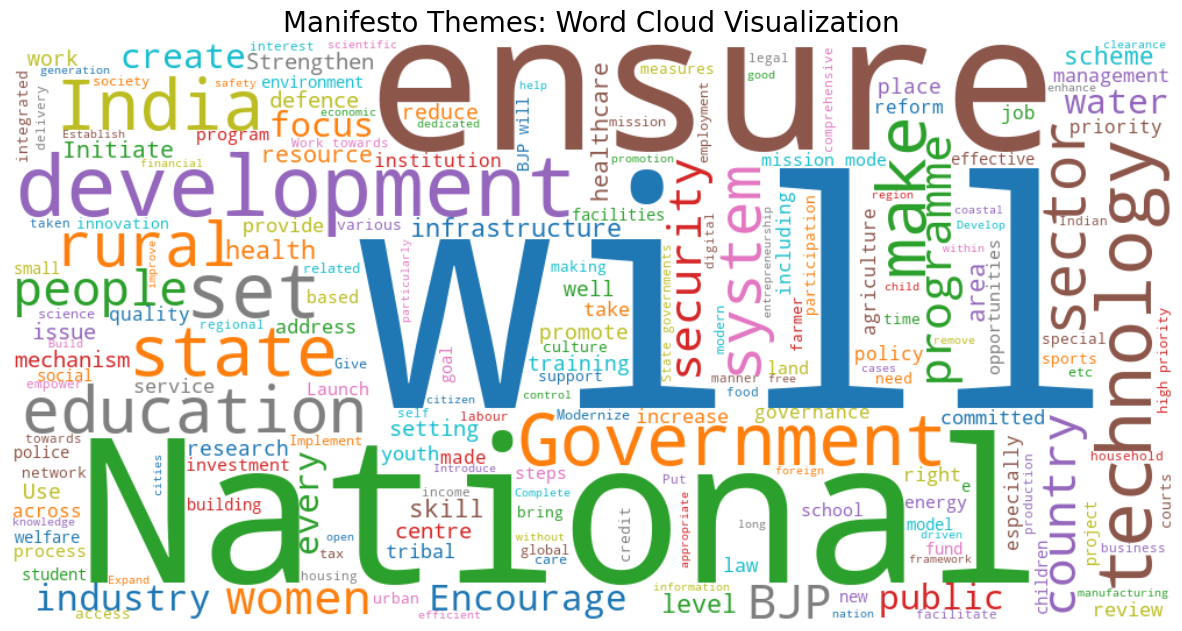

In [7]:
text = " ".join(df['original_text'].astype(str).tolist())
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='tab10').generate(text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Manifesto Themes: Word Cloud Visualization', fontsize=20)
plt.savefig('data/output/eda/wordcloud_manifesto.png')
plt.show()